In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from the local directory
df = pd.read_csv('Restaurant_Dataset.csv')

# Display the first 5 rows to verify successful data loading
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [8]:
# Determine the top 3 most common cuisines in the dataset
top_cuisines = df['Cuisines'].value_counts().head(3)
print("Top 3 Cuisines:\n", top_cuisines)

# Calculate the percentage of restaurants that serve each of the top cuisines
total_restaurants = len(df)
cuisine_percentages = (top_cuisines / total_restaurants) * 100
print("\nPercentages of Top Cuisines:\n", cuisine_percentages)

Top 3 Cuisines:
 Cuisines
North Indian             936
North Indian, Chinese    511
Chinese                  354
Name: count, dtype: int64

Percentages of Top Cuisines:
 Cuisines
North Indian             9.800021
North Indian, Chinese    5.350225
Chinese                  3.706418
Name: count, dtype: float64


In [9]:
# 1. Identify the city with the highest number of restaurants
top_city = df['City'].value_counts().idxmax()
print(f"City with the highest number of restaurants: {top_city}")

# 2. Calculate the average rating for restaurants in each city
avg_rating_per_city = df.groupby('City')['Aggregate rating'].mean()

# 3. Determine the city with the highest average rating
highest_rated_city = avg_rating_per_city.idxmax()
print(f"City with the highest average rating: {highest_rated_city} ({avg_rating_per_city.max():.2f})")

City with the highest number of restaurants: New Delhi
City with the highest average rating: Inner City (4.90)


Price Range Percentages:
 Price range
1    46.529159
2    32.593446
3    14.741912
4     6.135483
Name: count, dtype: float64


C:\Users\abhir\AppData\Local\Temp\ipykernel_26144\4112188817.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Price range', palette='viridis')


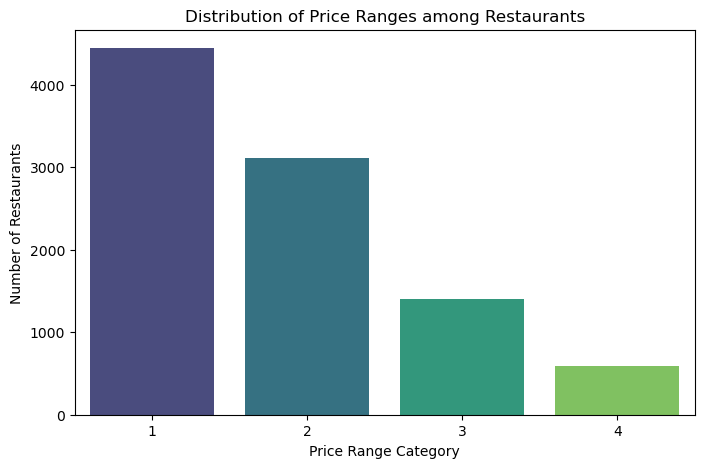

In [10]:
# Calculate the percentage of restaurants in each price range category
price_counts = df['Price range'].value_counts()
price_percentages = (price_counts / total_restaurants) * 100
print("Price Range Percentages:\n", price_percentages)

# Create a bar chart to visualize the distribution of price ranges
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Price range', palette='viridis')
plt.title('Distribution of Price Ranges among Restaurants')
plt.xlabel('Price Range Category')
plt.ylabel('Number of Restaurants')
plt.show()

In [11]:
# Determine the percentage of restaurants that offer online delivery
online_delivery_pct = df['Has Online delivery'].value_counts(normalize=True) * 100
print("Online Delivery Availability (%):\n", online_delivery_pct)

# Compare the average ratings of restaurants with and without online delivery
avg_rating_delivery = df.groupby('Has Online delivery')['Aggregate rating'].mean()
print("\nAverage Ratings Comparison (With vs Without Online Delivery):\n", avg_rating_delivery)

Online Delivery Availability (%):
 Has Online delivery
No     74.337766
Yes    25.662234
Name: proportion, dtype: float64

Average Ratings Comparison (With vs Without Online Delivery):
 Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64
